# Ironman 70.3 — Performance Analysis

Capstone project notebook.

In [2]:
# Core
import pandas as pd
import numpy as np
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn — models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Sklearn — metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
%matplotlib inline

# Ironman 70.3 Performance Analysis
## Capstone Project — UC Berkeley ML/AI Professional Certificate

### Business Understanding

Ironman 70.3 is one of the most popular long-distance triathlon formats in 
the world, consisting of a 1.9km swim, 90km bike and 21.1km run. Since 2004, 
hundreds of thousands of amateur athletes have competed in events across 
the globe.

Unlike professional athletes who have coaches and support teams, amateur 
triathletes often make training and race selection decisions based on 
intuition or generic advice. This project aims to provide data-driven 
answers to questions that any triathlete would find useful:

**Primary research question:**
Can we predict the finish time of an amateur athlete in an Ironman 70.3 
race based on their age, sex, country of origin and race location?

**Secondary research questions:**
1. Which race segment — swim, bike or run — has the greatest predictive 
   power over the final finish time?
2. Has the average performance of amateur athletes improved between 
   2004 and 2020, and in which segment has improvement been greatest?
3. How does performance vary across age groups, and in which segment 
   does it decline fastest with age?

### Why this matters
A model that can predict finish times and identify the most impactful 
race segment gives amateur athletes and their coaches a practical tool 
for smarter training decisions — one based on data from hundreds of 
thousands of real race results rather than assumptions.

In [3]:
# Load dataset
df = pd.read_csv('../data/ironman_703.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (840075, 13)

Columns: ['Gender', 'AgeGroup', 'AgeBand', 'Country', 'CountryISO2', 'EventYear', 'EventLocation', 'SwimTime', 'Transition1Time', 'BikeTime', 'Transition2Time', 'RunTime', 'FinishTime']


,Gender,AgeGroup,AgeBand,Country,CountryISO2,EventYear,EventLocation,SwimTime,Transition1Time,BikeTime,Transition2Time,RunTime,FinishTime
0,M,40-44,40,Andorra,AD,2019,IRONMAN 70.3 South American Championship Bueno...,1679,119,9107,95,5515,16514
1,M,45-49,45,Andorra,AD,2019,IRONMAN 70.3 South American Championship Bueno...,2070,177,9160,132,6070,17609
2,M,45-49,45,Andorra,AD,2020,IRONMAN 70.3 Bariloche,1667,161,9891,122,5190,17031
3,M,45-49,45,Andorra,AD,2019,IRONMAN 70.3 World Championship,1750,183,10363,160,5071,17527
4,M,40-44,40,Andorra,AD,2019,IRONMAN 70.3 World Championship,2063,182,10065,142,5556,18008


## Data Understanding

The dataset contains 840,075 finisher records from Ironman 70.3 races 
worldwide between 2004 and 2020. Each record represents one athlete's 
result in one race, including their demographic information and split 
times for each segment.

### Feature description

| Feature | Type | Description |
|---|---|---|
| Gender | Categorical | Athlete's sex (Male/Female) |
| AgeGroup | Categorical | Age group category |
| AgeBand | Categorical | Broader age band grouping |
| Country | Categorical | Athlete's country of origin |
| CountryISO2 | Categorical | ISO2 country code |
| EventYear | Numeric | Year of the race (2004-2020) |
| EventLocation | Categorical | Race location |
| SwimTime | Numeric | Swim split time |
| Transition1Time | Numeric | T1 transition time |
| BikeTime | Numeric | Bike split time |
| Transition2Time | Numeric | T2 transition time |
| RunTime | Numeric | Run split time |
| FinishTime | Numeric | Total finish time |

In [4]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 840075 entries, 0 to 840074
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   Gender           840075 non-null  str  
 1   AgeGroup         840075 non-null  str  
 2   AgeBand          840075 non-null  int64
 3   Country          840075 non-null  str  
 4   CountryISO2      840075 non-null  str  
 5   EventYear        840075 non-null  int64
 6   EventLocation    840075 non-null  str  
 7   SwimTime         840075 non-null  int64
 8   Transition1Time  840075 non-null  int64
 9   BikeTime         840075 non-null  int64
 10  Transition2Time  840075 non-null  int64
 11  RunTime          840075 non-null  int64
 12  FinishTime       840075 non-null  int64
dtypes: int64(8), str(5)
memory usage: 83.3 MB


In [5]:
# Descriptive statistics
df.describe()

,AgeBand,EventYear,SwimTime,Transition1Time,BikeTime,Transition2Time,RunTime,FinishTime
count,840075.00,840075.00,840075.00,840075.00,840075.00,840075.00,840075.00,840075.00
mean,36.90,2015.11,2340.25,286.68,10675.31,219.79,7606.97,21129.01
std,10.84,3.18,486.45,98.42,1397.95,94.24,1588.10,3076.23
min,0.00,2004.00,1201.00,46.00,6511.00,46.00,4002.00,13004.00
25%,30.00,2013.00,2010.00,211.00,9682.00,147.00,6440.00,18919.00
50%,35.00,2016.00,2286.00,280.00,10503.00,205.00,7362.00,20839.00
75%,45.00,2018.00,2604.00,359.00,11483.00,279.00,8544.00,23052.00
max,85.00,2020.00,5997.00,499.00,17993.00,499.00,14999.00,36529.00


In [6]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Missing values per column:
Gender             0
AgeGroup           0
AgeBand            0
Country            0
CountryISO2        0
EventYear          0
EventLocation      0
SwimTime           0
Transition1Time    0
BikeTime           0
Transition2Time    0
RunTime            0
FinishTime         0
dtype: int64

Total missing: 0

Unique values per column:
Gender: 2 unique values
AgeGroup: 15 unique values
AgeBand: 15 unique values
Country: 240 unique values
CountryISO2: 240 unique values
EventYear: 17 unique values
EventLocation: 195 unique values
SwimTime: 4058 unique values
Transition1Time: 454 unique values
BikeTime: 9687 unique values
Transition2Time: 454 unique values
RunTime: 9982 unique values
FinishTime: 18617 unique values


In [7]:
# Target variable distribution
print("FinishTime sample values:")
print(df['FinishTime'].head(10))
print(f"\nFinishTime dtype: {df['FinishTime'].dtype}")

FinishTime sample values:
0    16514
1    17609
2    17031
3    17527
4    18008
5    19655
6    21605
7    19627
8    17368
9    17489
Name: FinishTime, dtype: int64

FinishTime dtype: int64


In [8]:
# Time columns in seconds — convert to minutes for readability
time_cols = ['SwimTime', 'Transition1Time', 'BikeTime', 
             'Transition2Time', 'RunTime', 'FinishTime']

time_stats = df[time_cols].describe() / 60  # convert to minutes
time_stats.round(1)

,SwimTime,Transition1Time,BikeTime,Transition2Time,RunTime,FinishTime
count,14001.20,14001.20,14001.20,14001.20,14001.20,14001.20
mean,39.00,4.80,177.90,3.70,126.80,352.20
std,8.10,1.60,23.30,1.60,26.50,51.30
min,20.00,0.80,108.50,0.80,66.70,216.70
25%,33.50,3.50,161.40,2.40,107.30,315.30
50%,38.10,4.70,175.00,3.40,122.70,347.30
75%,43.40,6.00,191.40,4.60,142.40,384.20
max,100.00,8.30,299.90,8.30,250.00,608.80


In [9]:
# Categorical distributions
print(f"Gender:\n{df['Gender'].value_counts()}\n")
print(f"AgeBand unique values: {sorted(df['AgeBand'].unique())}")
print(f"\nAgeGroup sample: {df['AgeGroup'].unique()[:10]}")
print(f"\nEventYear range: {df['EventYear'].min()} - {df['EventYear'].max()}")
print(f"\nTop 10 countries:\n{df['Country'].value_counts().head(10)}")
print(f"\nTotal unique locations: {df['EventLocation'].nunique()}")
print(f"Top 10 locations:\n{df['EventLocation'].value_counts().head(10)}")

Gender:
Gender
M    635680
F    204395
Name: count, dtype: int64

AgeBand unique values: [np.int64(0), np.int64(18), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70), np.int64(75), np.int64(80), np.int64(85)]

AgeGroup sample: <StringArray>
['40-44', '45-49', '35-39', '50-54', '25-29', '18-24', '30-34', '55-59',
    '00', '60-64']
Length: 10, dtype: str

EventYear range: 2004 - 2020

Top 10 countries:
Country
United States     332037
Australia          59617
Canada             48233
Germany            37159
United Kingdom     36523
Mexico             25535
France             24026
Brazil             21851
South Africa       18376
Italy              13963
Name: count, dtype: int64

Total unique locations: 195
Top 10 locations:
EventLocation
IRONMAN 70.3 World Championship      26123
IRONMAN 70.3 Augusta                 23803
IRONMAN 70.3 Florida                 22576
IRONMAN 70.3 Texas             

In [10]:
# Check invalid age groups
invalid_age = df[df['AgeGroup'] == '00']
print(f"Records with AgeGroup '00': {len(invalid_age)}")
print(f"AgeBand 0 records: {(df['AgeBand'] == 0).sum()}")

# Check if they coincide
print(f"\nSample of invalid records:")
print(invalid_age.head())

Records with AgeGroup '00': 16611
AgeBand 0 records: 16611

Sample of invalid records:
    Gender AgeGroup  AgeBand               Country CountryISO2  EventYear  \
162      F       00        0  United Arab Emirates          AE       2020   
193      F       00        0  United Arab Emirates          AE       2020   
424      M       00        0  United Arab Emirates          AE       2011   
477      M       00        0  United Arab Emirates          AE       2012   
604      F       00        0              Anguilla          AI       2014   

                        EventLocation  SwimTime  Transition1Time  BikeTime  \
162  IRONMAN 70.3 Les Sables d'Olonne      1738              183      9276   
193                IRONMAN 70.3 Dubai      1702              164      8039   
424         IRONMAN 70.3 Asia-Pacific      1433               96      8638   
477   IRONMAN 70.3 World Championship      1449              163      7985   
604              IRONMAN 70.3 Raleigh      1454             

In [11]:
# Check for suspicious values — zeros or unrealistically low/high times
print("Zero values per time column:")
for col in time_cols:
    zeros = (df[col] == 0).sum()
    print(f"  {col}: {zeros} zeros")

print("\nMinimum values (in minutes):")
for col in time_cols:
    print(f"  {col}: {df[col].min()/60:.1f} min")

print("\nMaximum values (in minutes):")
for col in time_cols:
    print(f"  {col}: {df[col].max()/60:.1f} min")

Zero values per time column:
  SwimTime: 0 zeros
  Transition1Time: 0 zeros
  BikeTime: 0 zeros
  Transition2Time: 0 zeros
  RunTime: 0 zeros
  FinishTime: 0 zeros

Minimum values (in minutes):
  SwimTime: 20.0 min
  Transition1Time: 0.8 min
  BikeTime: 108.5 min
  Transition2Time: 0.8 min
  RunTime: 66.7 min
  FinishTime: 216.7 min

Maximum values (in minutes):
  SwimTime: 100.0 min
  Transition1Time: 8.3 min
  BikeTime: 299.9 min
  Transition2Time: 8.3 min
  RunTime: 250.0 min
  FinishTime: 608.8 min


In [12]:
# Remove invalid age group records
df_clean = df[df['AgeGroup'] != '00'].copy()
df_clean = df_clean[df_clean['AgeBand'] != 0].copy()

print(f"Original records:  {len(df):,}")
print(f"Clean records:     {len(df_clean):,}")
print(f"Records removed:   {len(df) - len(df_clean):,}")

Original records:  840,075
Clean records:     823,464
Records removed:   16,611


In [13]:
time_cols = ['SwimTime', 'Transition1Time', 'BikeTime',
             'Transition2Time', 'RunTime', 'FinishTime']

print("Minimum values (in minutes):")
for col in time_cols:
    print(f"  {col}: {df_clean[col].min()/60:.1f} min")

print("\nMaximum values (in minutes):")
for col in time_cols:
    print(f"  {col}: {df_clean[col].max()/60:.1f} min")

Minimum values (in minutes):
  SwimTime: 20.0 min
  Transition1Time: 0.8 min
  BikeTime: 108.5 min
  Transition2Time: 0.8 min
  RunTime: 66.7 min
  FinishTime: 224.2 min

Maximum values (in minutes):
  SwimTime: 100.0 min
  Transition1Time: 8.3 min
  BikeTime: 299.9 min
  Transition2Time: 8.3 min
  RunTime: 250.0 min
  FinishTime: 608.8 min


In [14]:
# Check finish times above 8h30min (510 minutes) — official cutoff
cutoff = 510 * 60  # in seconds
above_cutoff = df_clean[df_clean['FinishTime'] > cutoff]
print(f"Records above 8h30min cutoff: {len(above_cutoff):,}")
print(f"Percentage: {len(above_cutoff)/len(df_clean)*100:.2f}%")

# Check very fast finish times below 3h30min
below_fast = df_clean[df_clean['FinishTime'] < 210*60]
print(f"\nRecords below 3h30min: {len(below_fast):,}")

# Check extreme swim times above 80 min
extreme_swim = df_clean[df_clean['SwimTime'] > 80*60]
print(f"\nRecords with SwimTime > 80 min: {len(extreme_swim):,}")

# Check extreme run times above 4 hours
extreme_run = df_clean[df_clean['RunTime'] > 240*60]
print(f"Records with RunTime > 4 hours: {len(extreme_run):,}")

Records above 8h30min cutoff: 2,365
Percentage: 0.29%

Records below 3h30min: 0

Records with SwimTime > 80 min: 682
Records with RunTime > 4 hours: 193


In [15]:
# Remove records above official cutoff time (8h30min)
cutoff = 510 * 60  # seconds

df_clean = df_clean[df_clean['FinishTime'] <= cutoff].copy()

print(f"Final clean dataset: {len(df_clean):,} records")
print(f"Total removed from original: {len(df) - len(df_clean):,}")
print(f"\nFinal dataset breakdown:")
print(f"  Gender: M={len(df_clean[df_clean['Gender']=='M']):,} / F={len(df_clean[df_clean['Gender']=='F']):,}")
print(f"  Years: {df_clean['EventYear'].min()} - {df_clean['EventYear'].max()}")
print(f"  Locations: {df_clean['EventLocation'].nunique()}")
print(f"  Countries: {df_clean['Country'].nunique()}")
print(f"  Age groups: {sorted(df_clean['AgeGroup'].unique())}")

Final clean dataset: 821,099 records
Total removed from original: 18,976

Final dataset breakdown:
  Gender: M=624,346 / F=196,753
  Years: 2004 - 2020
  Locations: 195
  Countries: 240
  Age groups: ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89']


In [16]:
# Add time columns in minutes for easier interpretation
time_cols = ['SwimTime', 'Transition1Time', 'BikeTime',
             'Transition2Time', 'RunTime', 'FinishTime']

for col in time_cols:
    df_clean[f'{col}_min'] = (df_clean[col] / 60).round(2)

print("New columns added (in minutes):")
print(df_clean[['SwimTime_min', 'BikeTime_min', 'RunTime_min', 'FinishTime_min']].describe().round(1))

New columns added (in minutes):
       SwimTime_min  BikeTime_min  RunTime_min  FinishTime_min
count     821099.00     821099.00    821099.00       821099.00
mean          39.20        178.40       127.40          353.50
std            7.90         22.60        25.80           49.20
min           20.00        108.50        66.70          224.20
25%           33.80        162.10       108.20          317.20
50%           38.30        175.50       123.20          348.40
75%           43.50        191.60       142.70          384.70
max          100.00        299.60       249.70          510.00


## Exploratory Data Analysis (EDA)

We explore the data across four dimensions:
1. Overall finish time distribution
2. Performance by gender
3. Performance by age group
4. Performance trends over time (2004-2020)

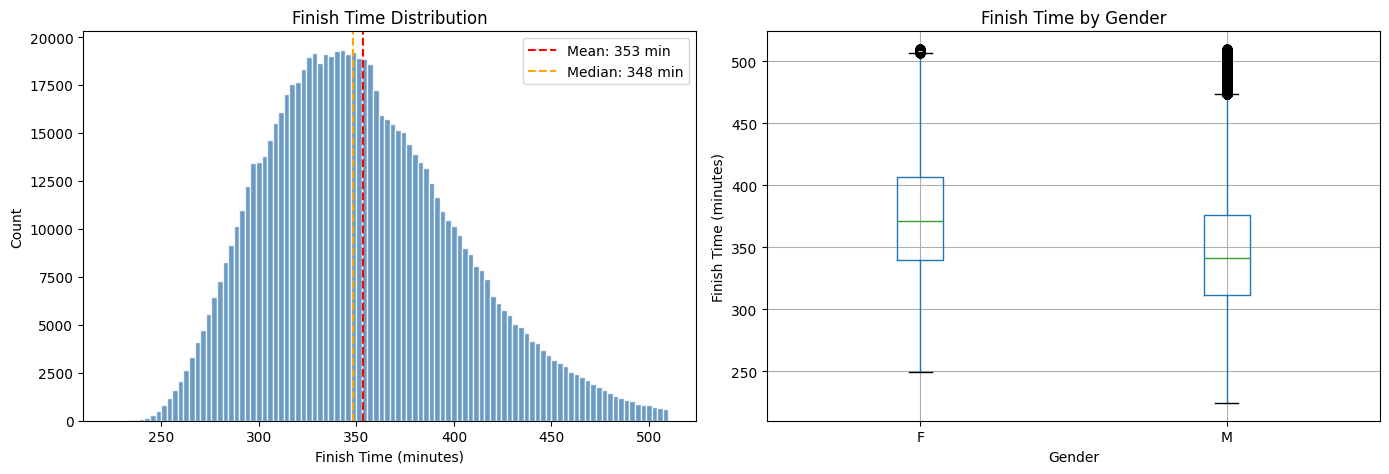

Finish time stats by gender (minutes):
           count   mean   std    min    25%    50%    75%    max
Gender                                                          
F      196753.00 375.30 47.80 249.60 339.70 371.00 406.60 510.00
M      624346.00 346.60 47.70 224.20 311.50 341.40 376.20 510.00


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['FinishTime_min'], bins=100, 
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df_clean['FinishTime_min'].mean(), 
                color='red', linestyle='--', 
                label=f"Mean: {df_clean['FinishTime_min'].mean():.0f} min")
axes[0].axvline(df_clean['FinishTime_min'].median(), 
                color='orange', linestyle='--',
                label=f"Median: {df_clean['FinishTime_min'].median():.0f} min")
axes[0].set_xlabel('Finish Time (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Finish Time Distribution')
axes[0].legend()

# Boxplot by gender
df_clean.boxplot(column='FinishTime_min', by='Gender', ax=axes[1])
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Finish Time (minutes)')
axes[1].set_title('Finish Time by Gender')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Stats by gender
print("Finish time stats by gender (minutes):")
print(df_clean.groupby('Gender')['FinishTime_min'].describe().round(1))

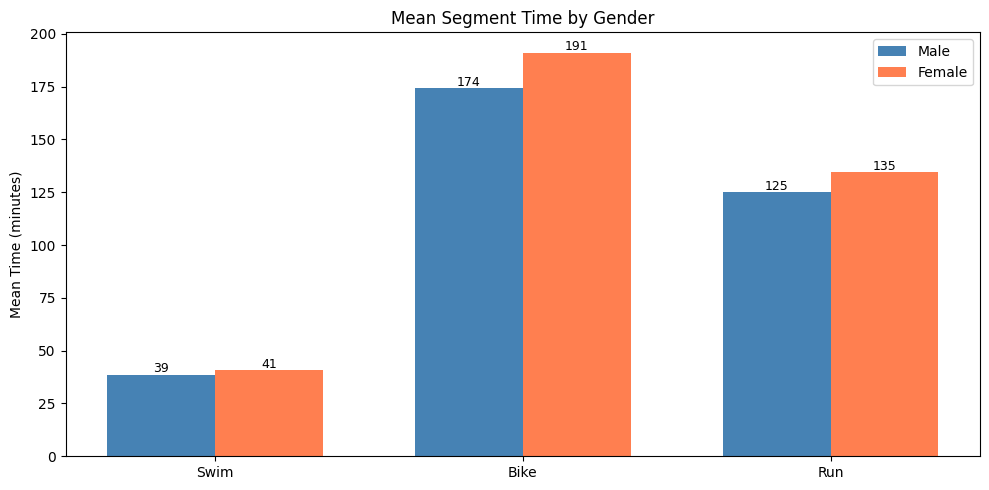


Mean segment times by gender (minutes):
        SwimTime_min  BikeTime_min  RunTime_min
Gender                                         
F              40.80        191.20       134.60
M              38.70        174.40       125.10


In [18]:
# Mean time per segment by gender
segments = ['SwimTime_min', 'BikeTime_min', 'RunTime_min']
segment_labels = ['Swim', 'Bike', 'Run']

gender_segments = df_clean.groupby('Gender')[segments].mean()

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(segment_labels))
width = 0.35

bars_m = ax.bar([i - width/2 for i in x], 
                gender_segments.loc['M'], 
                width, label='Male', color='steelblue')
bars_f = ax.bar([i + width/2 for i in x], 
                gender_segments.loc['F'], 
                width, label='Female', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(segment_labels)
ax.set_ylabel('Mean Time (minutes)')
ax.set_title('Mean Segment Time by Gender')
ax.legend()

# Add value labels on bars
for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 1,
            f'{bar.get_height():.0f}', 
            ha='center', fontsize=9)
for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 1,
            f'{bar.get_height():.0f}', 
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nMean segment times by gender (minutes):")
print(gender_segments.round(1))

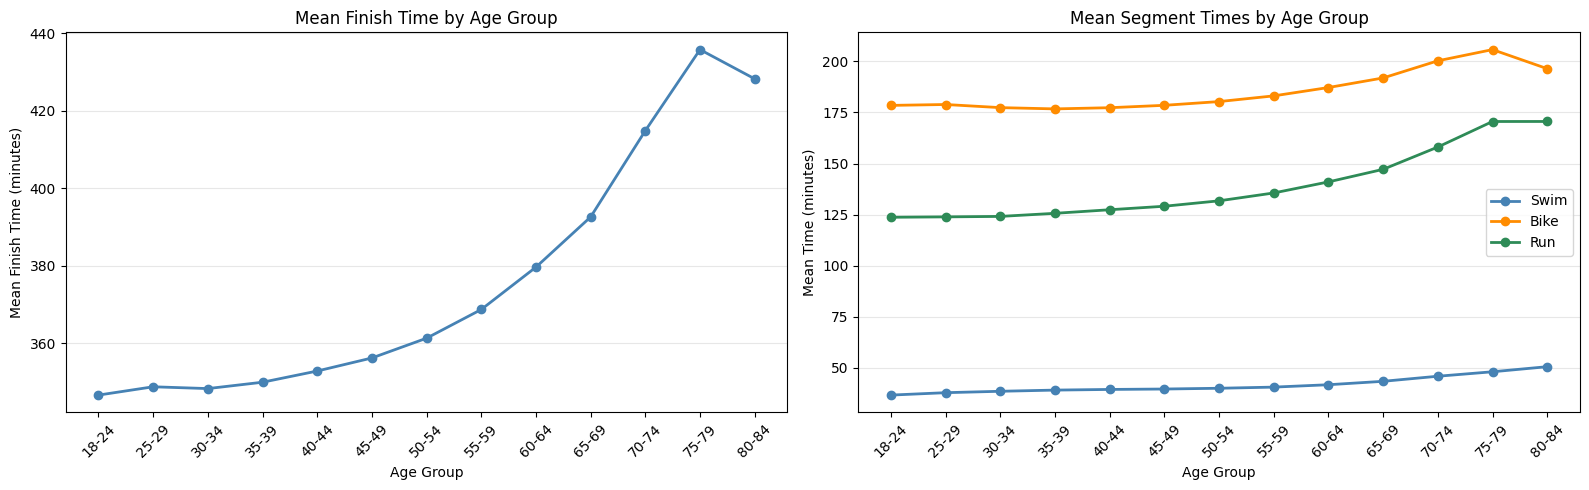

In [19]:
# Age groups ordered
age_order = ['18-24', '25-29', '30-34', '35-39', '40-44',
             '45-49', '50-54', '55-59', '60-64', '65-69',
             '70-74', '75-79', '80-84', '85+']

# Filter only existing age groups
existing_ages = [a for a in age_order if a in df_clean['AgeGroup'].unique()]

age_perf = df_clean[df_clean['AgeGroup'].isin(existing_ages)]\
    .groupby('AgeGroup')[['FinishTime_min'] + segments].mean()
age_perf = age_perf.reindex(existing_ages)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Finish time by age group
axes[0].plot(existing_ages, age_perf['FinishTime_min'], 
             marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Mean Finish Time (minutes)')
axes[0].set_title('Mean Finish Time by Age Group')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Segment times by age group
for seg, label, color in zip(segments, segment_labels, 
                              ['steelblue', 'darkorange', 'seagreen']):
    axes[1].plot(existing_ages, age_perf[seg], 
                 marker='o', label=label, color=color, linewidth=2)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Mean Time (minutes)')
axes[1].set_title('Mean Segment Times by Age Group')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

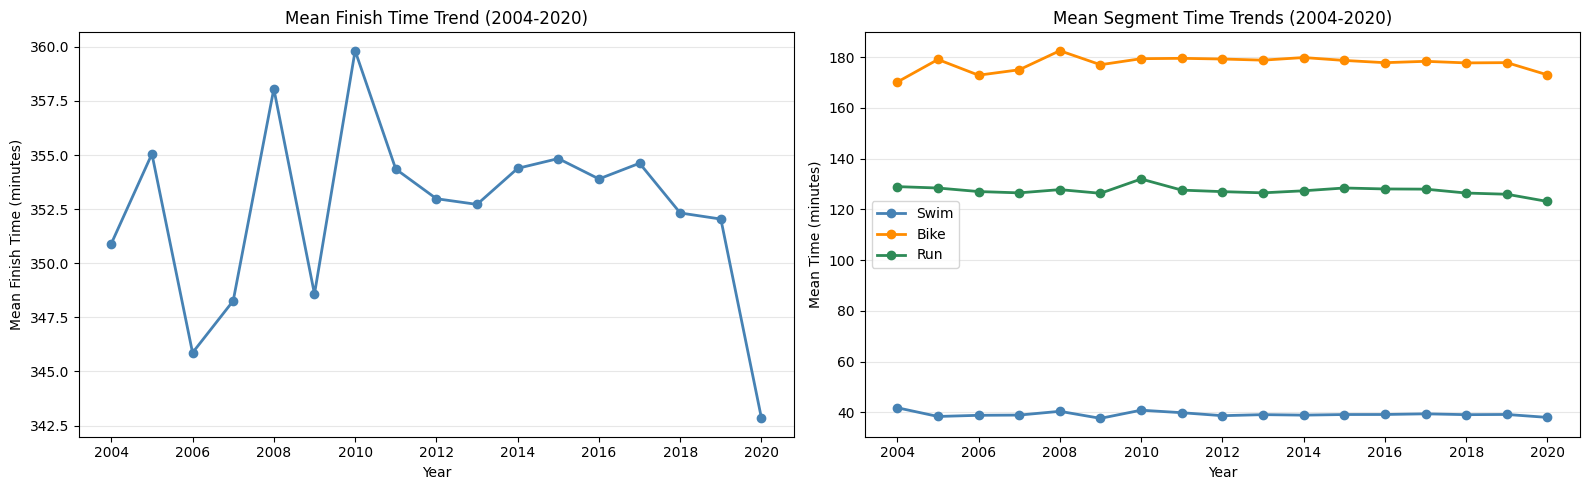


Mean times by year (minutes):
           FinishTime_min  SwimTime_min  BikeTime_min  RunTime_min
EventYear                                                         
2004               350.90         41.80        170.20       129.00
2005               355.10         38.40        179.10       128.40
2006               345.90         38.80        172.90       127.00
2007               348.30         38.90        175.00       126.50
2008               358.10         40.40        182.60       127.80
2009               348.60         37.60        177.00       126.40
2010               359.80         40.90        179.40       132.00
2011               354.40         39.90        179.60       127.60
2012               353.00         38.70        179.30       127.00
2013               352.70         39.10        178.80       126.50
2014               354.40         38.90        179.90       127.30
2015               354.80         39.10        178.70       128.40
2016               353.90      

In [20]:
# Mean finish time per year
yearly = df_clean.groupby('EventYear')[['FinishTime_min'] + segments].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall finish time trend
axes[0].plot(yearly.index, yearly['FinishTime_min'], 
             marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Finish Time (minutes)')
axes[0].set_title('Mean Finish Time Trend (2004-2020)')
axes[0].grid(axis='y', alpha=0.3)

# Segment trends
for seg, label, color in zip(segments, segment_labels,
                              ['steelblue', 'darkorange', 'seagreen']):
    axes[1].plot(yearly.index, yearly[seg],
                 marker='o', label=label, color=color, linewidth=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Time (minutes)')
axes[1].set_title('Mean Segment Time Trends (2004-2020)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMean times by year (minutes):")
print(yearly.round(1))

## EDA Summary and Key Findings

After exploring the data, which contains 821,099 amateur finisher records 
from Ironman 70.3 races between 2004 and 2020, here are the main things 
I found interesting.

### 1. Overall finish time distribution
The average finish time is around 354 minutes (about 5h54), but there is 
quite a lot of variability — the standard deviation is 49 minutes, which 
means athletes finishing between 5 and 7 hours are all fairly common. 
Looking at the distribution, more athletes finish above the mean than 
below it, which I think makes sense because the slowest athletes can 
take much longer than the fastest ones.

### 2. Performance by gender
Male athletes finish about 28 minutes faster on average than female 
athletes (347 min vs 375 min). What surprised me here is that the spread 
of performance is almost the same for both groups — men and women show 
similar variability around their respective averages, they just race at 
different speeds overall.

When I broke this down by segment, most of the gender gap comes from 
the bike (about 17 minutes difference), which accounts for nearly 60% 
of the total time difference between genders. The swim showed the 
smallest gap (about 2 minutes), which I found interesting — I would 
have expected a bigger difference there too.

### 3. Performance by age group
This was probably the most interesting part of the EDA for me personally, 
as a triathlete. Performance is fairly stable between ages 25 and 39, 
and starts declining noticeably after 45, accelerating quite sharply 
after 60.

What I did not expect was which segment deteriorates the most with age. 
I assumed it would be the bike, since it is the longest and most 
physically demanding segment. But the data shows it is actually the run 
that declines the fastest — run times increase by about 47 minutes from 
the youngest to the oldest age groups, compared to 26 minutes for bike 
and only 12 minutes for swim. That was genuinely surprising to me and 
something I want to explore further in the modeling phase.

The small improvement seen in the 80-84 group compared to 75-79 also 
caught my attention. I think this might be because only the most 
exceptional athletes are still competing at that age, which would pull 
the average down — but I am not sure about this and it would be worth 
investigating further.

### 4. Performance trends over time (2004-2020)
I honestly expected to see a clear improvement in finish times over 
16 years — the sport has grown enormously, equipment has improved and 
training resources are much more accessible now than in 2004. But the 
data tells a different story: average finish times have barely changed 
at all, consistently hovering around 350-360 minutes throughout the 
entire period.

One thing that stands out is 2020, which shows the fastest average 
finish time of the whole dataset (342.8 min). My guess is that this 
is because most races were cancelled due to COVID-19 that year, so 
only a smaller and probably more experienced group of athletes competed 
— which would naturally bring the average down. But I cannot confirm 
this from the data alone.

The swim segment also shows more variation year to year than bike and 
run, which might be related to differences in water conditions across 
different race locations and years.

### What this means for the next steps
Going into the modeling phase, a few things stand out from this 
exploration:
- Gender and age group are clearly related to finish time and should 
  be useful features for the model.
- Event year does not seem to add much given how stable times are 
  across the period, but I will include it and let the model decide.
- The bike dominates in absolute time, but the run seems to matter 
  more as athletes get older — I want to see if the model picks 
  this up too.
- I am curious to see whether swim, bike and run times individually 
  can predict the overall finish time, and which one the model 
  considers most important.